In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score
import numpy as np

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [ ]:
data_dir = "/content/drive/MyDrive/mtech"  # change accordingly

train_dir = os.path.join(data_dir, "Training")
val_dir   = os.path.join(data_dir, "Validation")

In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [ ]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset   = datasets.ImageFolder(val_dir, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

num_classes = len(train_dataset.classes)
print("Classes:", train_dataset.classes)

Classes: ['grade0', 'grade1', 'grade2', 'grade3']


In [ ]:
model = models.resnet50(pretrained=True)

# Freeze backbone (optional)
for param in model.parameters():
    param.requires_grad = False

# Replace final FC layer
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 143MB/s]


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc

In [ ]:
def validate(model, loader, criterion):
    model.eval()
    running_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc

In [ ]:
num_epochs = 10

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = validate(model, val_loader, criterion)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.6f} | Train Acc: {train_acc:.6f}")
    print(f"Val   Loss: {val_loss:.6f} | Val   Acc: {val_acc:.6f}")
    print("-"*40)

Epoch [1/10]
Train Loss: 0.901842 | Train Acc: 0.756767
Val   Loss: 0.821553 | Val   Acc: 0.817857
----------------------------------------
Epoch [2/10]
Train Loss: 0.746966 | Train Acc: 0.791291
Val   Loss: 0.710877 | Val   Acc: 0.782143
----------------------------------------
Epoch [3/10]
Train Loss: 0.648320 | Train Acc: 0.815222
Val   Loss: 0.635741 | Val   Acc: 0.825000
----------------------------------------
Epoch [4/10]
Train Loss: 0.592051 | Train Acc: 0.822283
Val   Loss: 0.583658 | Val   Acc: 0.814286
----------------------------------------
Epoch [5/10]
Train Loss: 0.539763 | Train Acc: 0.845822
Val   Loss: 0.537182 | Val   Acc: 0.850000
----------------------------------------
Epoch [6/10]
Train Loss: 0.505214 | Train Acc: 0.849353
Val   Loss: 0.502506 | Val   Acc: 0.835714
----------------------------------------
Epoch [7/10]
Train Loss: 0.475578 | Train Acc: 0.863084
Val   Loss: 0.465125 | Val   Acc: 0.850000
----------------------------------------
Epoch [8/10]
Train L

In [ ]:
torch.save(model.state_dict(), "/content/drive/MyDrive/resnet50_model.pth")

In [1]:
import os
import copy
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [6]:
data_dir = "/content/drive/MyDrive/mtech"

base_dataset = datasets.ImageFolder(data_dir)
targets = np.array(base_dataset.targets)
num_classes = len(base_dataset.classes)

In [7]:
class CustomDataset(Dataset):
    def __init__(self, dataset, indices, transform=None):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        image, label = self.dataset[self.indices[idx]]
        if self.transform:
            image = self.transform(image)
        return image, label

In [8]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

num_epochs = 10
batch_size = 32
fold_accuracies = []

In [9]:
for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(targets)), targets)):

    print(f"\n===== Fold {fold+1} =====")

    train_dataset = CustomDataset(base_dataset, train_idx, transform=train_transform)
    val_dataset   = CustomDataset(base_dataset, val_idx, transform=val_transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Fresh model each fold
    model = models.resnet50(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    # Training
    for epoch in range(num_epochs):

        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # Validation
    model.eval()
    val_preds = []
    val_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    fold_acc = accuracy_score(val_labels, val_preds)
    fold_accuracies.append(fold_acc)

    print(f"Fold {fold+1} Accuracy: {fold_acc:.4f}")


===== Fold 1 =====


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 124MB/s]


Fold 1 Accuracy: 0.9534

===== Fold 2 =====


...

Fold 3 Accuracy: 0.9550

===== Fold 4 =====


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Fold 4 Accuracy: 0.9469

===== Fold 5 =====


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Fold 5 Accuracy: 0.9614


In [10]:
print("\n===== FINAL 5-FOLD RESULTS =====")
for i, acc in enumerate(fold_accuracies):
    print(f"Fold {i+1}: {acc:.4f}")

print(f"\nMean Accuracy: {np.mean(fold_accuracies):.4f}")
print(f"Std Deviation: {np.std(fold_accuracies):.4f}")


===== FINAL 5-FOLD RESULTS =====
Fold 1: 0.9534
Fold 2: 0.9437
Fold 3: 0.9550
Fold 4: 0.9469
Fold 5: 0.9614

Mean Accuracy: 0.9521
Std Deviation: 0.0062


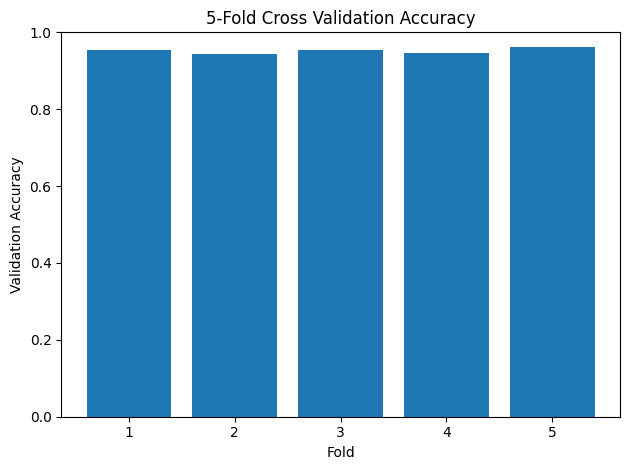

In [11]:
import matplotlib.pyplot as plt
import numpy as np

fold_numbers = np.arange(1, len(fold_accuracies) + 1)

plt.figure()
plt.bar(fold_numbers, fold_accuracies)

plt.xlabel("Fold")
plt.ylabel("Validation Accuracy")
plt.title("5-Fold Cross Validation Accuracy")
plt.xticks(fold_numbers)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

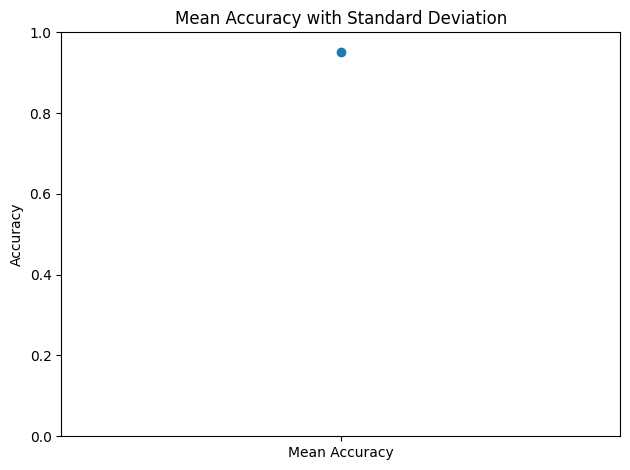

Mean Accuracy: 0.9521
Std Deviation: 0.0062


In [12]:
mean_acc = np.mean(fold_accuracies)
std_acc = np.std(fold_accuracies)

plt.figure()
plt.errorbar(1, mean_acc, yerr=std_acc, fmt='o')

plt.xlim(0.5, 1.5)
plt.ylim(0, 1)
plt.xticks([1], ["Mean Accuracy"])
plt.ylabel("Accuracy")
plt.title("Mean Accuracy with Standard Deviation")

plt.tight_layout()
plt.show()

print(f"Mean Accuracy: {mean_acc:.4f}")
print(f"Std Deviation: {std_acc:.4f}")

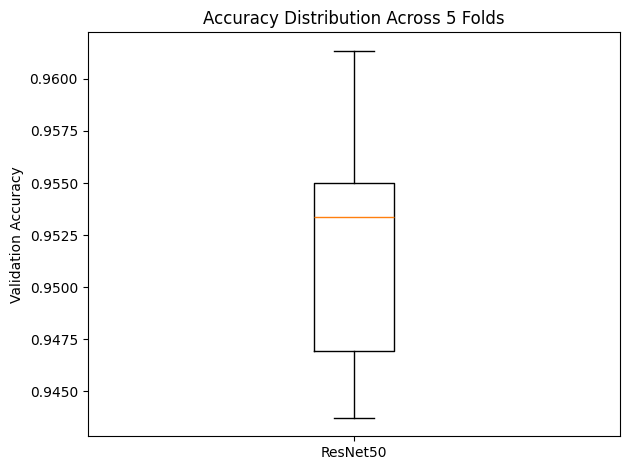

In [13]:
plt.figure()
plt.boxplot(fold_accuracies)

plt.ylabel("Validation Accuracy")
plt.title("Accuracy Distribution Across 5 Folds")
plt.xticks([1], ["ResNet50"])

plt.tight_layout()
plt.show()

In [14]:
# Before starting CV
fold_true_labels_list = []
fold_probs_list = []
fold_preds_list = []
class_names = base_dataset.classes

In [15]:
model.eval()
val_preds = []
val_labels = []
val_probs = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        val_labels.extend(labels.cpu().numpy())
        val_preds.extend(preds.cpu().numpy())
        val_probs.extend(probs.cpu().numpy())

# Store for later visualization
fold_true_labels_list.append(val_labels)
fold_preds_list.append(val_preds)
fold_probs_list.append(val_probs)